**Install and Import Libraries**

In [21]:
# Install required packages
!pip install xgboost lightgbm statsmodels catboost openpyxl -q

# Core libraries
import pandas as pd
import numpy as np

# Machine learning models
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor


# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt

# File download (Google Colab)
from google.colab import files

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


**Load Dataset**

In [22]:
filename = 'cinnamon_production_final_V3.xlsx'

df = pd.read_excel(filename)

print("📊 DATA PREVIEW")
print(df.head(3))
print(f"Total months: {len(df)}")

print("Columns:")
print(df.columns)

📊 DATA PREVIEW
   Year  Month  Monthly_Production_ton  Monthly_Export_ton  \
0  2000      1                  809.40          606.283417   
1  2000      2                  890.34          667.241505   
2  2000      3                  944.30          707.680384   

   Average_Price_LKR_per_kg  Rainfall_mm  USD_Exchange_rate  \
0                183.334173   560.399995            72.3583   
1                183.334173   801.799992            72.8335   
2                183.334173   714.100002            73.0855   

   Average_temperature  
0            26.696585  
1            27.254277  
2            27.123465  
Total months: 276
Columns:
Index(['Year', 'Month', 'Monthly_Production_ton', 'Monthly_Export_ton',
       'Average_Price_LKR_per_kg', 'Rainfall_mm', 'USD_Exchange_rate',
       'Average_temperature'],
      dtype='object')


**Create Date Index**

In [23]:
df['date'] = pd.to_datetime(df[['Year','Month']].assign(day=1))
df.set_index('date', inplace=True)

print(f"✅ Date range: {df.index[0].strftime('%Y-%m')} → {df.index[-1].strftime('%Y-%m')}")

✅ Date range: 2000-01 → 2022-12


**Select Core Variables**

In [24]:
core_vars = [
'Monthly_Production_ton',
'Monthly_Export_ton',
'Average_Price_LKR_per_kg',
'Rainfall_mm',
'USD_Exchange_rate',
'Average_temperature'
]

df = df[core_vars].copy()

**Feature Engineering**

In [25]:
df['month'] = df.index.month

df['prod_lag1'] = df['Monthly_Production_ton'].shift(1)
df['prod_lag3'] = df['Monthly_Production_ton'].shift(3)
df['prod_lag12'] = df['Monthly_Production_ton'].shift(12)

df['export_lag1'] = df['Monthly_Export_ton'].shift(1)
df['price_lag1'] = df['Average_Price_LKR_per_kg'].shift(1)

# Rainfall
df['rainfall_lag1'] = df['Rainfall_mm'].shift(1)
df['rainfall_3m'] = df['Rainfall_mm'].rolling(3).mean().shift(1)
df['rainfall_6m'] = df['Rainfall_mm'].rolling(6).mean().shift(1)

# USD
df['usd_lag1'] = df['USD_Exchange_rate'].shift(1)
df['usd_3m_avg'] = df['USD_Exchange_rate'].rolling(3).mean().shift(1)
df['usd_change'] = df['USD_Exchange_rate'].pct_change().shift(1)

df['price_usd'] = df['Average_Price_LKR_per_kg'] / df['USD_Exchange_rate']

# Temperature
df['temp_lag1'] = df['Average_temperature'].shift(1)
df['temp_3m'] = df['Average_temperature'].rolling(3).mean().shift(1)
df['temp_deviation'] = df['Average_temperature'] - 26

df['heat_stress'] = (df['Average_temperature'] > 30).astype(int)

df = df.dropna()

print(f"✅ Dataset ready: {len(df)} months")

✅ Dataset ready: 264 months


**Feature List**

In [26]:
features = [
'month',
'prod_lag1',
'prod_lag12',
'export_lag1',
'price_lag1',
'rainfall_lag1',
'rainfall_3m',
'rainfall_6m',
'prod_lag3',
'usd_lag1',
'usd_3m_avg',
'usd_change',
'price_usd',
'temp_lag1',
'temp_3m',
'temp_deviation',
'heat_stress'
]

X = df[features]
y = df['Monthly_Production_ton']

**Train Test Split**

In [27]:
split = int(len(X)*0.7)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(f"TRAIN: {len(X_train)} months")
print(f"TEST: {len(X_test)} months")

TRAIN: 184 months
TEST: 80 months


**Feature Scaling**

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train Multiple Models**

In [29]:
models = {

"XGBoost": xgb.XGBRegressor(
n_estimators=200,
learning_rate=0.03,
max_depth=5,
random_state=42),

"Random Forest": RandomForestRegressor(
n_estimators=300,
max_depth=10,
random_state=42),

"LightGBM": lgb.LGBMRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=6,
random_state=42),

"CatBoost": CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)
}

results=[]
trained_models={}
predictions={}

**Model Training Loop**

In [30]:
for name, model in models.items():

    print("\n"+"="*70)
    print(f"🚀 TRAINING {name}")
    print("="*70)

    model.fit(X_train_scaled, y_train)

    y_pred=model.predict(X_test_scaled)

    mae=mean_absolute_error(y_test,y_pred)
    mape=100*np.mean(np.abs((y_test-y_pred)/y_test))
    r2=r2_score(y_test,y_pred)*100

    print(f"MAE: {mae:.0f} tons")
    print(f"MAPE: {mape:.1f}%")
    print(f"R²: {r2:.1f}%")

    results.append([name,mae,mape,r2])

    trained_models[name]=model
    predictions[name]=y_pred


🚀 TRAINING XGBoost
MAE: 124 tons
MAPE: 6.5%
R²: 85.5%

🚀 TRAINING Random Forest
MAE: 160 tons
MAPE: 8.4%
R²: 74.5%

🚀 TRAINING LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 909
[LightGBM] [Info] Number of data points in the train set: 184, number of used features: 16
[LightGBM] [Info] Start training from score 1277.535328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

**Model Comparison Chart**


🏆 MODEL COMPARISON
           Model         MAE      MAPE         R2
0        XGBoost  124.260139  6.470986  85.494626
1  Random Forest  159.757742  8.422390  74.483780
2       LightGBM  179.258477  8.853475  61.400973
3       CatBoost  163.881643  7.733644  66.833525


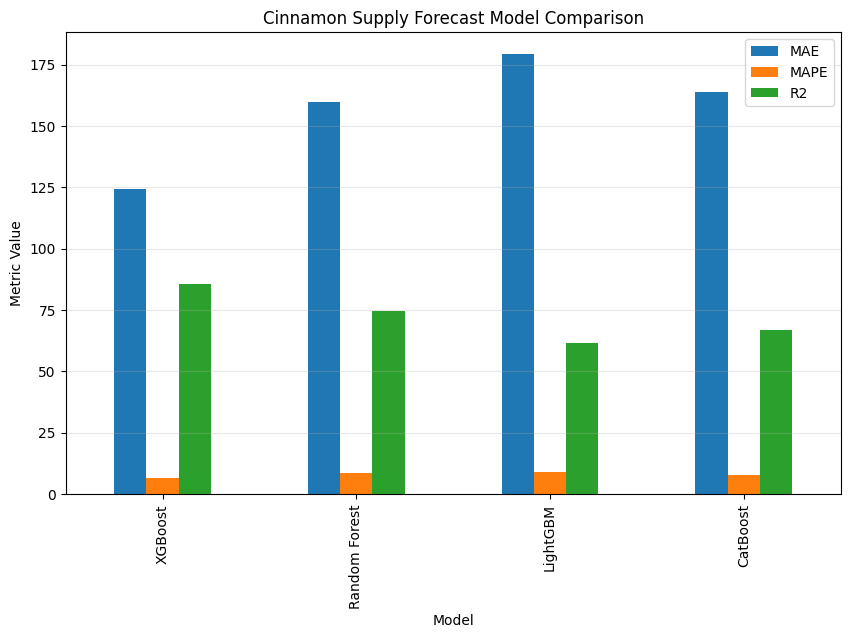

In [31]:
results_df=pd.DataFrame(results,columns=["Model","MAE","MAPE","R2"])

print("\n🏆 MODEL COMPARISON")
print(results_df)

results_df.set_index("Model").plot(kind="bar",figsize=(10,6))

plt.title("Cinnamon Supply Forecast Model Comparison")
plt.ylabel("Metric Value")
plt.grid(axis='y',alpha=0.3)

plt.show()

**Forecast Comparison Plot**

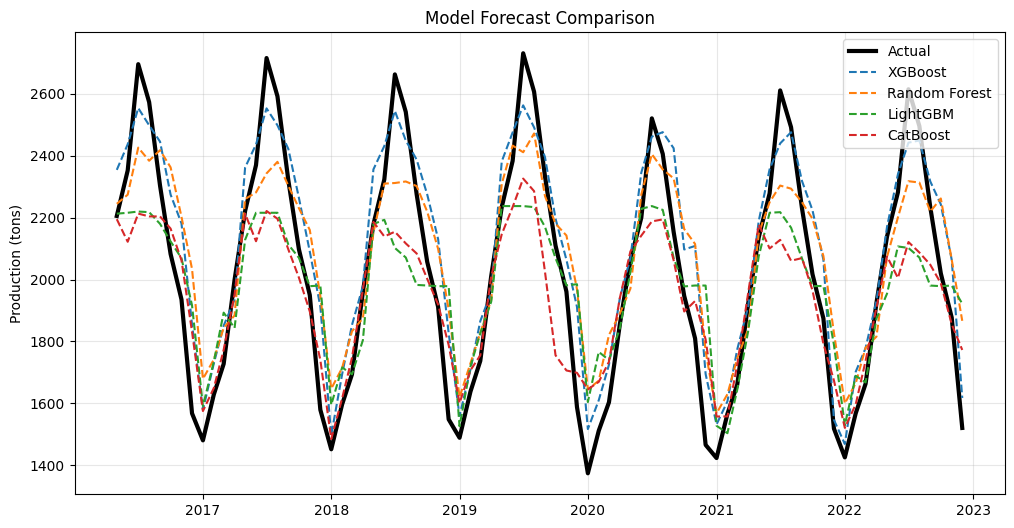

In [32]:
plt.figure(figsize=(12,6))

plt.plot(df.index[split:],y_test.values,'k-',label="Actual",linewidth=3)

for name,pred in predictions.items():
    plt.plot(df.index[split:],pred,'--',label=name)

plt.title("Model Forecast Comparison")
plt.ylabel("Production (tons)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Feature Importance**

In [33]:
for name,model in trained_models.items():

    if hasattr(model,"feature_importances_"):

        importance=pd.DataFrame({
        "feature":features,
        "importance":model.feature_importances_
        }).sort_values("importance",ascending=False)

        print(f"\n📊 {name} Top Features")
        print(importance.head(10))


📊 XGBoost Top Features
           feature  importance
2       prod_lag12    0.511211
1        prod_lag1    0.227752
9         usd_lag1    0.136883
0            month    0.023772
7      rainfall_6m    0.019974
8        prod_lag3    0.019411
6      rainfall_3m    0.017907
15  temp_deviation    0.011723
14         temp_3m    0.009397
13       temp_lag1    0.005855

📊 Random Forest Top Features
          feature  importance
2      prod_lag12    0.516576
1       prod_lag1    0.375856
9        usd_lag1    0.025570
10     usd_3m_avg    0.017062
0           month    0.011981
8       prod_lag3    0.011333
7     rainfall_6m    0.010494
6     rainfall_3m    0.007712
14        temp_3m    0.004735
5   rainfall_lag1    0.004027

📊 LightGBM Top Features
          feature  importance
8       prod_lag3         266
2      prod_lag12         240
14        temp_3m         216
1       prod_lag1         192
10     usd_3m_avg         127
12      price_usd         113
4      price_lag1          86
6     rain

**Future Forecast (24 Months)**

In [36]:
model=trained_models["XGBoost"]

future_steps=24
future_preds=[]

last_row = X_test_scaled[-1].reshape(1,-1).copy()

for i in range(future_steps):

    pred=model.predict(last_row)[0]
    future_preds.append(pred)

    last_row[0,1]=pred

future_dates=pd.date_range(
start=df.index[-1]+pd.DateOffset(months=1),
periods=24,
freq='MS'
)

forecast_df=pd.DataFrame({
"Year":future_dates.year,
"Month":future_dates.month,
"Forecast_tons":[round(x,1) for x in future_preds]
})

print(forecast_df.head(12))

forecast_df.to_excel("cinnamon_supply_forecast.xlsx",index=False)

    Year  Month  Forecast_tons
0   2023      1    1617.599976
1   2023      2    2011.099976
2   2023      3    2011.099976
3   2023      4    2011.099976
4   2023      5    2011.099976
5   2023      6    2011.099976
6   2023      7    2011.099976
7   2023      8    2011.099976
8   2023      9    2011.099976
9   2023     10    2011.099976
10  2023     11    2011.099976
11  2023     12    2011.099976


**Download Results**

In [ ]:
files.download("cinnamon_supply_forecast.xlsx")

print("🎉 Forecast file ready")

In [40]:
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge

print("\n" + "="*70)
print("🤝 TRAINING STACKED ENSEMBLE (CROSS-VALIDATION)")
print("="*70)

# Number of folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Storage for meta-features
stack_train = np.zeros((X_train_scaled.shape[0], 3))
stack_test = np.zeros((X_test_scaled.shape[0], 3))

base_models = [
    ("XGBoost", xgb.XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=5, random_state=42)),
    ("Random Forest", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ("CatBoost", CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42))
]

for model_idx, (name, model) in enumerate(base_models):

    print(f"\nTraining base model: {name}")

    test_fold_preds = []

    for train_idx, val_idx in kf.split(X_train_scaled):

        X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        # Out-of-fold predictions
        stack_train[val_idx, model_idx] = model.predict(X_val)

        # Test predictions
        test_fold_preds.append(model.predict(X_test_scaled))

    stack_test[:, model_idx] = np.mean(test_fold_preds, axis=0)

# Train meta model
meta_model = Ridge()

meta_model.fit(stack_train, y_train)

# Final stacked prediction
y_pred_stack = meta_model.predict(stack_test)

# Evaluation
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mape_stack = 100*np.mean(np.abs((y_test - y_pred_stack)/y_test))
r2_stack = r2_score(y_test, y_pred_stack)*100

print("\nSTACKED MODEL RESULTS")
print(f"MAE: {mae_stack:.2f}")
print(f"MAPE: {mape_stack:.2f}%")
print(f"R²: {r2_stack:.2f}%")

results.append(["Stacked Ensemble (CV)", mae_stack, mape_stack, r2_stack])


🤝 TRAINING STACKED ENSEMBLE (CROSS-VALIDATION)

Training base model: XGBoost

Training base model: Random Forest

Training base model: CatBoost

STACKED MODEL RESULTS
MAE: 148.68
MAPE: 7.73%
R²: 76.91%



🏆 MODEL COMPARISON
                   Model         MAE      MAPE         R2
0                XGBoost  124.260139  6.470986  85.494626
1          Random Forest  159.757742  8.422390  74.483780
2               LightGBM  179.258477  8.853475  61.400973
3               CatBoost  163.881643  7.733644  66.833525
4       Stacked Ensemble   82.217970  4.112721  92.697448
5  Stacked Ensemble (CV)  148.684460  7.734779  76.911409


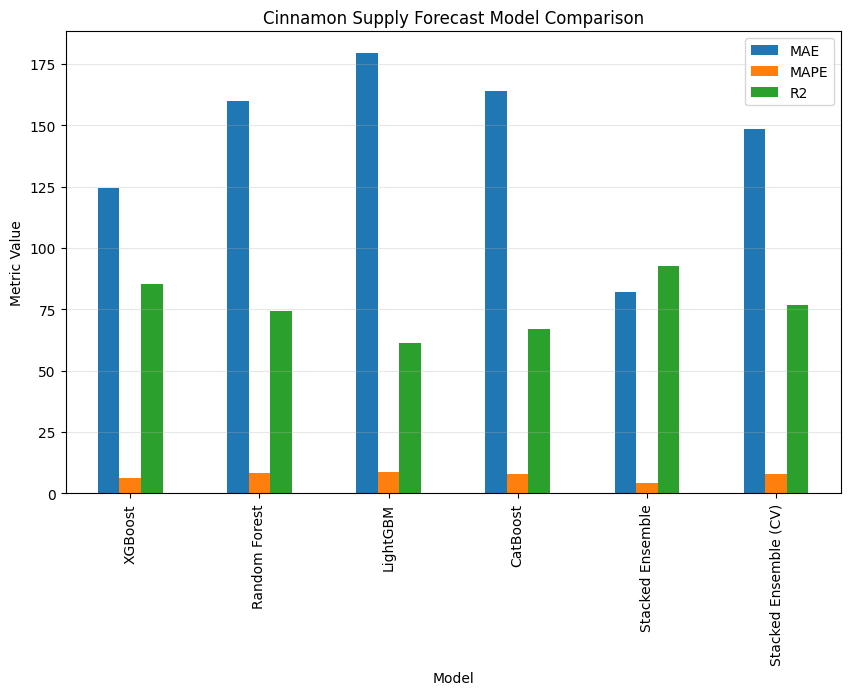

In [41]:
results_df = pd.DataFrame(results, columns=["Model","MAE","MAPE","R2"])

print("\n🏆 MODEL COMPARISON")
print(results_df)

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Cinnamon Supply Forecast Model Comparison")
plt.ylabel("Metric Value")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df.index[split:], y_test.values, label="Actual", linewidth=3)

for name, pred in predictions.items():
    plt.plot(df.index[split:], pred, '--', label=name)

plt.title("Model Forecast Comparison")
plt.ylabel("Production (tons)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()